# ₿ Bitcoin Forecasting Model Factory
### AI Personal Finance Coach — Deep Learning Module

This notebook is the **single source of truth** for the Bitcoin forecasting model used by the
application server (`server.ipynb`). It performs the complete pipeline, end to end:

| Stage | What happens |
|---|---|
| **1. Load** | Reads `datasets/btc/btc.csv` (train, 2010→2024, stored in *reverse* chronological order) and `datasets/btc/btc_test.csv` (2024→2029). |
| **2. Clean** | Ascending sort, strict date continuity, zero-era removal, OHLC coherence repair, hard **no-NaN / no-zero** assertions with printed proof. |
| **3. Features** | 20 causal, stationary features — log-returns, volatility, RSI, MACD, Bollinger %B, SMA ratios, ROC, volume dynamics, day-of-week encoding. **No raw price ever enters the model.** |
| **4. Targets** | Direct multi-horizon: the **10 next-day log-returns** `[r(t+1) … r(t+10)]`, outlier-clipped at train-only percentiles. |
| **5. Split** | Train = historical data · Validation = **first year of the test file** (2024-06-28 → 2025-06-27) · Final evaluation = the remaining test data — exactly as specified, chronological, leakage-checked by assertion. |
| **6. Model** | `Conv1D → LSTM(96) → LSTM(48) → Dense` with Huber loss, AdamW, gradient clipping, dropout, EarlyStopping / ReduceLROnPlateau / ModelCheckpoint. |
| **7. Evaluate** | Walk-forward, per-horizon RMSE / MAE / MAPE / directional accuracy, honestly benchmarked against **persistence** and **drift** baselines. |
| **8. Calibrate** | UP / DOWN / HOLD signal thresholds calibrated on validation, with quantified uncertainty. |
| **9. Ship** | Saves `data/btc/model.keras`, `data/btc/scalers.pkl`, `data/btc/metadata.json`, then reload-verifies and demonstrates the exact serving path `server.ipynb` will use. |

**Honesty notes (also encoded in the metadata artifact):**
- Daily BTC returns are close to a random walk; the realistic goal is a *small, measurable* edge over
  naive baselines with quantified uncertainty — not "price prediction".
- The test file's dates run to **2029**, i.e. it is a synthetic future series. Final-evaluation numbers
  therefore measure generalization to a *simulated* regime; this is stated wherever metrics are reported.

In [1]:
# =============================================================================
# 1 · ENVIRONMENT, DETERMINISM & CONFIGURATION
# =============================================================================
import os
import json
import pickle
import random
import warnings
from datetime import datetime, timezone

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # silence TF info/warning spam
os.environ["PYTHONHASHSEED"] = "42"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import RobustScaler, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
try:
    # Full op-level determinism. Slightly slower; comment out if you need raw speed.
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

CONFIG = {
    # --- paths -------------------------------------------------------------
    "train_csv":      "datasets/btc/btc.csv",
    "test_csv":       "datasets/btc/btc_test.csv",
    "artifacts_dir":  "data/btc",
    # --- split contract (per competition spec) ------------------------------
    #   validation = first year of the test file, final eval = the remainder
    "val_end_date":   "2025-06-27",
    # --- sequence design -----------------------------------------------------
    "lookback": 60,          # days of context fed to the network
    "horizon":  10,          # days predicted (direct multi-output)
    # --- cleaning ------------------------------------------------------------
    "zero_era_run": 30,      # require 30 consecutive days of Volume>0 & MarketCap>0
    "max_gap_days": 2,       # forward-fill calendar gaps up to this length, else abort
    "target_clip_pct": (0.5, 99.5),   # train-only percentile clip on target returns
    # --- model ----------------------------------------------------------------
    "conv_filters": 48,
    "lstm1": 96,
    "lstm2": 48,
    "dense": 48,
    "dropout": 0.25,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "batch_size": 64,
    "max_epochs": 200,
    "patience_early_stop": 50,
    "patience_reduce_lr": 6,
}

ART_DIR       = CONFIG["artifacts_dir"]
MODEL_PATH    = os.path.join(ART_DIR, "model.keras")
SCALERS_PATH  = os.path.join(ART_DIR, "scalers.pkl")
METADATA_PATH = os.path.join(ART_DIR, "metadata.json")
os.makedirs(ART_DIR, exist_ok=True)

print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")
print(f"GPU devices: {tf.config.list_physical_devices('GPU') or 'none (CPU training — fine for this data size)'}")
print(f"Artifacts  → {os.path.abspath(ART_DIR)}")

TensorFlow : 2.16.2
NumPy      : 1.26.4
Pandas     : 3.0.5
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Artifacts  → /Users/sam/Desktop/aiolearn/My_projects/innoverse_mansory_edition/data/btc


## 2 · Data loading

Known quirks of the provided files, handled explicitly below:

- `btc.csv` is stored **newest-first** and begins with a UTF-8 BOM → read with `utf-8-sig`, sort ascending.
- `btc_test.csv` uses `"YYYY-MM-DD 23:59:59"` in its `End` column → we key everything on `Start` (date only).
- Train ends **2024-06-27**, test begins **2024-06-28** — perfectly contiguous. The two files come from
  different sources, so there is one small price discontinuity at the seam (~−2.7% overnight); it is a
  single ordinary-magnitude return and needs no special treatment.
- Train and test are concatenated into one continuous daily series so that rolling indicators are
  computed **once, causally, without warm-up gaps** at the split boundary. Split discipline is enforced
  later at the *sample* level (with assertions), which is the correct place to enforce it.

In [2]:
# =============================================================================
# 2 · LOAD RAW DATA
# =============================================================================
REQUIRED_COLUMNS = ["Start", "End", "Open", "High", "Low", "Close", "Volume", "Market Cap"]
NUMERIC_COLUMNS  = ["Open", "High", "Low", "Close", "Volume", "Market Cap"]


def load_ohlcv(path: str) -> pd.DataFrame:
    """Load one of the provided BTC CSVs into an ascending, Start-indexed frame."""
    df = pd.read_csv(path, encoding="utf-8-sig")
    df.columns = [c.strip() for c in df.columns]
    missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    assert not missing, f"{path}: missing required columns {missing}"

    # 'Start' may be 'YYYY-MM-DD' or 'YYYY-MM-DD hh:mm:ss' — keep the date part only.
    df["Start"] = pd.to_datetime(df["Start"].astype(str).str.slice(0, 10), format="%Y-%m-%d")
    for c in NUMERIC_COLUMNS:
        df[c] = pd.to_numeric(df[c], errors="raise")

    df = (df.drop(columns=["End"])
            .sort_values("Start")
            .drop_duplicates(subset="Start", keep="first")
            .set_index("Start"))
    return df


train_raw = load_ohlcv(CONFIG["train_csv"])
test_raw  = load_ohlcv(CONFIG["test_csv"])

TRAIN_LAST_DATE = train_raw.index.max()            # boundary of trainable history
TEST_START_DATE = test_raw.index.min()
VAL_END_DATE    = pd.Timestamp(CONFIG["val_end_date"])

assert TRAIN_LAST_DATE < TEST_START_DATE, "train/test overlap detected"
assert (TEST_START_DATE - TRAIN_LAST_DATE).days == 1, "train and test are not contiguous"

df = pd.concat([train_raw, test_raw]).sort_index()
df = df[~df.index.duplicated(keep="first")]

print(f"train file : {len(train_raw):>5} rows   {train_raw.index.min().date()} → {train_raw.index.max().date()}")
print(f"test  file : {len(test_raw):>5} rows   {test_raw.index.min().date()} → {test_raw.index.max().date()}")
print(f"combined   : {len(df):>5} rows   {df.index.min().date()} → {df.index.max().date()}")
print(f"split plan : train ≤ {TRAIN_LAST_DATE.date()} | validation {TEST_START_DATE.date()} → {VAL_END_DATE.date()} | final test > {VAL_END_DATE.date()}")

train file :  5095 rows   2010-07-17 → 2024-06-27
test  file :  1825 rows   2024-06-28 → 2029-06-26
combined   :  6920 rows   2010-07-17 → 2029-06-26
split plan : train ≤ 2024-06-27 | validation 2024-06-28 → 2025-06-27 | final test > 2025-06-27


## 3 · Data cleaning — *no zeros, no NaNs, no gaps, no incoherent candles*

Cleaning policy (each rule enforced with a hard assertion at the end):

1. **Calendar continuity** — BTC trades every calendar day; the daily index must be complete.
   Gaps of ≤ 2 days are forward-filled (and reported); anything longer aborts the run loudly.
2. **Zero-era removal** — the earliest years of the training file carry `Volume = 0` and
   `Market Cap = 0` (pre-liquid market). Instead of imputing fiction, we **drop everything before the
   first 30-consecutive-day run of strictly positive Volume *and* Market Cap**. This satisfies the
   no-zeros requirement *legitimately* and discards a sub-$100 price regime that is statistically
   toxic to scaling anyway. Since features are return-space, no useful signal is lost.
3. **OHLC coherence repair** — enforce `Low ≤ min(Open, Close)` and `High ≥ max(Open, Close)` by
   widening High/Low where a vendor glitch violates it (count reported).
4. **Positivity** — every OHLCV/MarketCap value must end up strictly `> 0`.
5. **Proof** — a final assertion cell prints a verification table: zero NaNs, zero zeros,
   zero negative values, perfectly monotonic daily index.

In [3]:
# =============================================================================
# 3 · CLEAN
# =============================================================================
# --- 3.1  calendar continuity ------------------------------------------------
full_index = pd.date_range(df.index.min(), df.index.max(), freq="D")
missing_days = full_index.difference(df.index)
if len(missing_days) > 0:
    gap_groups = (pd.Series(missing_days)
                    .diff().dt.days.ne(1).cumsum())
    max_run = int(gap_groups.value_counts().max())
    assert max_run <= CONFIG["max_gap_days"], (
        f"calendar gap of {max_run} days found — data is broken, refusing to impute")
    df = df.reindex(full_index).ffill()
    print(f"calendar gaps      : {len(missing_days)} missing day(s) forward-filled (max run {max_run})")
else:
    print("calendar gaps      : none — daily index already complete")
df.index.name = "Start"

# --- 3.2  zero-era removal -----------------------------------------------------
liquid = ((df["Volume"] > 0) & (df["Market Cap"] > 0)).astype(float)
run_ok = liquid.rolling(CONFIG["zero_era_run"]).min() == 1.0
first_liquid_day = run_ok[run_ok].index[0] - pd.Timedelta(days=CONFIG["zero_era_run"] - 1)
dropped = int((df.index < first_liquid_day).sum())
df = df.loc[first_liquid_day:]
print(f"zero-era removal   : dropped {dropped} pre-liquidity rows — series now starts {df.index.min().date()}")

# Defensive sweep: any *isolated* residual zero/negative in Volume or Market Cap inside the
# liquid era (vendor glitch) is repaired by forward-fill from the previous liquid day.
for col in ("Volume", "Market Cap"):
    bad = int((df[col] <= 0).sum())
    if bad:
        df[col] = df[col].mask(df[col] <= 0).ffill()
        print(f"residual repair    : {bad} non-positive value(s) in {col!r} forward-filled")

# --- 3.3  OHLC coherence repair -------------------------------------------------
lo_fix = int((df["Low"]  > df[["Open", "Close"]].min(axis=1)).sum())
hi_fix = int((df["High"] < df[["Open", "Close"]].max(axis=1)).sum())
df["Low"]  = df[["Low", "Open", "Close"]].min(axis=1)
df["High"] = df[["High", "Open", "Close"]].max(axis=1)
print(f"OHLC coherence     : widened Low on {lo_fix} row(s), High on {hi_fix} row(s)")

# --- 3.4  hard verification (the printed proof) ----------------------------------
checks = pd.DataFrame({
    "NaN count":      df.isna().sum(),
    "zero count":     (df == 0).sum(),
    "negative count": (df < 0).sum(),
    "min":            df.min(),
    "max":            df.max(),
})
print("\n=== CLEANLINESS PROOF ===")
print(checks)

assert df.isna().sum().sum() == 0,            "NaNs survived cleaning"
assert (df <= 0).sum().sum() == 0,            "zero / negative values survived cleaning"
assert df.index.is_monotonic_increasing,       "index not sorted"
assert (df.index.to_series().diff().dropna() == pd.Timedelta(days=1)).all(), "index not strictly daily"
assert (df["Low"] <= df[["Open", "Close"]].min(axis=1)).all()
assert (df["High"] >= df[["Open", "Close"]].max(axis=1)).all()
print(f"\nALL ASSERTIONS PASSED — {len(df)} clean daily rows, {df.index.min().date()} → {df.index.max().date()}")

calendar gaps      : none — daily index already complete
zero-era removal   : dropped 1259 pre-liquidity rows — series now starts 2013-12-27
OHLC coherence     : widened Low on 0 row(s), High on 0 row(s)

=== CLEANLINESS PROOF ===
            NaN count  zero count  negative count                min  \
Open                0           0               0           178.1030   
High                0           0               0           211.7310   
Low                 0           0               0           171.5100   
Close               0           0               0           178.7950   
Volume              0           0               0     2,688,736.1458   
Market Cap          0           0               0 2,690,696,718.5837   

                              max  
Open                 122,371.6900  
High                 122,632.8400  
Low                  121,265.1900  
Close                122,301.8100  
Volume       212,151,513,117.8704  
Market Cap 2,419,570,587,921.0000  

ALL ASSERTI

## 4 · Feature engineering — 20 causal, stationary features

**The decisive design choice: no raw price enters the model.** An LSTM fed raw prices collapses the
moment test prices leave the training range (and here the test regime *is* different). Every feature
below is a return, ratio, oscillator, or bounded statistic — stationary encodings that generalize
across price regimes.

| Group | Features | Rationale |
|---|---|---|
| Returns | `log_ret` | the primary signal carrier |
| Candle geometry | `hl_range`, `close_pos` | intraday volatility & buying/selling pressure |
| Volume dynamics | `log_vol_chg`, `vol_ratio` | participation shifts precede moves |
| Realized volatility | `volat_7/14/30` | regime awareness at three time scales |
| Momentum oscillators | `rsi_14`, `roc_7`, `roc_14` | over-extension & momentum |
| Trend (MACD on log-price) | `macd`, `macd_signal`, `macd_hist` | trend strength & turning points |
| Mean-reversion | `bb_pctb` | position inside the Bollinger envelope |
| Trend ratios | `close_sma7/21/50` (log Close/SMA) | stationary trend encodings |
| Seasonality | `dow_sin`, `dow_cos` | weekly cycle (weekend liquidity effects) |

Every indicator is **backward-looking only** (rolling / EWM over past values), so computing them once
over the concatenated series leaks nothing. The rolling warm-up head (≤ 50 rows) is dropped and the
frame is re-asserted NaN-free and finite.

In [4]:
# =============================================================================
# 4 · FEATURES
# =============================================================================
def compute_features(ohlcv: pd.DataFrame) -> pd.DataFrame:
    """20 causal stationary features. Every column uses ONLY past/current values."""
    c, h, l, v = ohlcv["Close"], ohlcv["High"], ohlcv["Low"], ohlcv["Volume"]
    logc = np.log(c)
    r = logc.diff()

    feat = pd.DataFrame(index=ohlcv.index)
    feat["log_ret"] = r

    # --- candle geometry ---
    rng = h - l
    feat["hl_range"]  = rng / c
    feat["close_pos"] = ((c - l) / rng.replace(0, np.nan)).fillna(0.5)   # doji → neutral 0.5

    # --- volume dynamics ---
    logv = np.log(v)
    feat["log_vol_chg"] = logv.diff()
    feat["vol_ratio"]   = np.log(v / v.rolling(20).mean())

    # --- realized volatility, three scales ---
    for w in (7, 14, 30):
        feat[f"volat_{w}"] = r.rolling(w).std()

    # --- RSI-14 (Wilder smoothing), scaled to [0, 1] ---
    delta = c.diff()
    gain  = delta.clip(lower=0).ewm(alpha=1 / 14, adjust=False).mean()
    loss  = (-delta.clip(upper=0)).ewm(alpha=1 / 14, adjust=False).mean()
    rs    = gain / loss.replace(0, np.nan)
    feat["rsi_14"] = ((100 - 100 / (1 + rs)) / 100.0).fillna(0.5)

    # --- MACD on LOG price (price-scale invariant) ---
    ema12 = logc.ewm(span=12, adjust=False).mean()
    ema26 = logc.ewm(span=26, adjust=False).mean()
    macd  = ema12 - ema26
    sig   = macd.ewm(span=9, adjust=False).mean()
    feat["macd"], feat["macd_signal"], feat["macd_hist"] = macd, sig, macd - sig

    # --- Bollinger %B (20d), clipped to a sane envelope ---
    m20, s20 = c.rolling(20).mean(), c.rolling(20).std()
    feat["bb_pctb"] = ((c - (m20 - 2 * s20)) / (4 * s20).replace(0, np.nan)).clip(-0.5, 1.5)

    # --- stationary trend ratios ---
    for w in (7, 21, 50):
        feat[f"close_sma{w}"] = np.log(c / c.rolling(w).mean())

    # --- momentum / rate of change ---
    feat["roc_7"]  = logc.diff(7)
    feat["roc_14"] = logc.diff(14)

    # --- weekly seasonality ---
    dow = ohlcv.index.dayofweek
    feat["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    feat["dow_cos"] = np.cos(2 * np.pi * dow / 7)
    return feat


feat_raw = compute_features(df).dropna()          # drop rolling warm-up head only
feat_raw = feat_raw.replace([np.inf, -np.inf], np.nan)
assert feat_raw.isna().sum().sum() == 0, "NaN/inf leaked into the feature matrix"

FEATURE_NAMES = list(feat_raw.columns)
close_aligned = df["Close"].reindex(feat_raw.index)

print(f"feature matrix : {feat_raw.shape[0]} rows × {feat_raw.shape[1]} features "
      f"({feat_raw.index.min().date()} → {feat_raw.index.max().date()})")
print(f"features       : {FEATURE_NAMES}")
feat_raw.describe().T[["mean", "std", "min", "max"]]

feature matrix : 5612 rows × 20 features (2014-02-14 → 2029-06-26)
features       : ['log_ret', 'hl_range', 'close_pos', 'log_vol_chg', 'vol_ratio', 'volat_7', 'volat_14', 'volat_30', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'bb_pctb', 'close_sma7', 'close_sma21', 'close_sma50', 'roc_7', 'roc_14', 'dow_sin', 'dow_cos']


,mean,std,min,max
log_ret,0.0007,0.0346,-0.5181,0.2509
hl_range,0.0408,0.0374,0.0000,0.6919
close_pos,0.5251,0.3167,0.0000,1.0000
log_vol_chg,0.0014,0.3576,-2.0129,2.2921
vol_ratio,-0.0442,0.3698,-1.9407,1.8328
volat_7,0.0291,0.0186,0.0020,0.2177
volat_14,0.0303,0.0166,0.0026,0.1612
volat_30,0.0313,0.0146,0.0052,0.1128
rsi_14,0.5208,0.1386,0.0885,0.9392
macd,0.0047,0.0434,-0.1527,0.2050


## 5 · Target engineering — direct multi-horizon log-returns

For an anchor day *t*, the target vector is the **10 next daily log-returns**
`y(t) = [r(t+1), …, r(t+10)]`.

Why this beats the alternatives:

- **Direct multi-output vs. recursive single-step** — recursive forecasting compounds its own error
  ten times; direct multi-horizon trains one head per day-ahead and makes each horizon's error
  measurable in isolation.
- **Log-returns vs. raw prices** — stationary targets, and the full 10-day *price path* is
  reconstructed exactly: `P(t+k) = P(t) · exp(Σᵢ₌₁ᵏ r(t+i))`.
- **Train-only outlier clipping** — daily crypto returns are violently heavy-tailed (flash crashes).
  Targets are clipped at the **0.5 / 99.5 percentiles of the *training* period only** so a handful of
  extreme days cannot dominate the loss. Validation/test *inputs* are never touched; the clip bounds
  are persisted so serving remains consistent.

In [5]:
# =============================================================================
# 5 · TARGETS
# =============================================================================
HORIZON = CONFIG["horizon"]
log_ret = feat_raw["log_ret"]

# Column h1 … h10:  r(t+1) … r(t+10)  aligned to anchor date t
targets_raw = pd.DataFrame(
    {f"h{k}": log_ret.shift(-k) for k in range(1, HORIZON + 1)},
    index=feat_raw.index,
)

# Train-only clip bounds (leakage-safe: computed strictly on rows ≤ TRAIN_LAST_DATE)
train_returns = log_ret.loc[:TRAIN_LAST_DATE]
CLIP_LO, CLIP_HI = np.percentile(train_returns, CONFIG["target_clip_pct"])
targets = targets_raw.clip(CLIP_LO, CLIP_HI)

n_clipped = int(((targets_raw < CLIP_LO) | (targets_raw > CLIP_HI)).sum().sum())
print(f"clip bounds (train-only p{CONFIG['target_clip_pct'][0]}/p{CONFIG['target_clip_pct'][1]}): "
      f"[{CLIP_LO:+.4f}, {CLIP_HI:+.4f}]  (≈ {np.expm1(CLIP_LO)*100:+.2f}% / {np.expm1(CLIP_HI)*100:+.2f}% daily)")
print(f"target cells clipped: {n_clipped} of {targets_raw.size} ({100*n_clipped/targets_raw.size:.2f}%)")
print(f"targets shape       : {targets.shape}  (last {HORIZON} anchor rows are NaN by construction and excluded below)")

clip bounds (train-only p0.5/p99.5): [-0.1325, +0.1221]  (≈ -12.41% / +12.98% daily)
target cells clipped: 390 of 56120 (0.69%)
targets shape       : (5612, 10)  (last 10 anchor rows are NaN by construction and excluded below)


## 6 · Chronological split · leakage-safe scaling · sequence construction

**Sample assignment** (an anchor *t* owns targets *t+1 … t+10*):

| Split | Rule | Consequence |
|---|---|---|
| Train | target **end** `t+10` ≤ 2024-06-27 | training never sees a single post-boundary value |
| Validation | targets entirely inside 2024-06-28 → 2025-06-27 | model selection touches only the first test year |
| Final test | target **start** `t+1` > 2025-06-27 | untouched until the very end |

Samples whose target block straddles a boundary are **dropped** (≈ 10 per boundary) rather than
fudged. Input windows may reach *backward* across a boundary for context — that is past data and
perfectly legal.

**Scaling** — `RobustScaler` on features (median/IQR: correct for heavy-tailed financial data) and
`StandardScaler` on targets, both **fit exclusively on training-period rows** and persisted to
`scalers.pkl` so serving applies byte-identical transforms.

Everything is wrapped in `build_sequences(lookback)` so the hyperparameter search can rebuild
datasets for different lookbacks without code duplication.

In [6]:
# =============================================================================
# 6 · SPLIT · SCALE · SEQUENCE
# =============================================================================
DATES = feat_raw.index.to_numpy()                    # continuous daily index
Y_RAW_ALL = targets.to_numpy(dtype=np.float64)       # clipped log-return targets
CLOSE_ALL = close_aligned.to_numpy(dtype=np.float64)
LOGRET_ALL = feat_raw["log_ret"].to_numpy(dtype=np.float64)
N_ROWS = len(feat_raw)


def build_sequences(lookback: int) -> dict:
    """Build leakage-safe train/val/test tensors for a given lookback window."""
    # ---- fit scalers on TRAIN-period rows only --------------------------------
    train_row_mask = feat_raw.index <= TRAIN_LAST_DATE
    feature_scaler = RobustScaler().fit(feat_raw.to_numpy()[train_row_mask])
    feat_scaled = feature_scaler.transform(feat_raw.to_numpy()).astype(np.float32)

    train_anchor_mask = train_row_mask & ~np.isnan(Y_RAW_ALL).any(axis=1)
    # (target NaNs only occur at the series tail, but keep the guard general)
    target_scaler = StandardScaler().fit(Y_RAW_ALL[train_anchor_mask & (
        pd.Series(DATES).add(pd.Timedelta(days=HORIZON)).to_numpy() <= np.datetime64(TRAIN_LAST_DATE))])

    splits = {name: {"X": [], "y": [], "y_scaled": [], "close": [], "drift": [], "dates": []}
              for name in ("train", "val", "test")}
    dropped_straddle = 0

    for i in range(lookback - 1, N_ROWS - HORIZON):
        y = Y_RAW_ALL[i]
        if np.isnan(y).any():
            continue
        t_first = pd.Timestamp(DATES[i + 1])            # date of target r(t+1)
        t_last  = pd.Timestamp(DATES[i + HORIZON])      # date of target r(t+10)

        if t_last <= TRAIN_LAST_DATE:
            split = "train"
        elif t_first >= TEST_START_DATE and t_last <= VAL_END_DATE:
            split = "val"
        elif t_first > VAL_END_DATE:
            split = "test"
        else:
            dropped_straddle += 1                        # target block crosses a boundary
            continue

        s = splits[split]
        s["X"].append(feat_scaled[i - lookback + 1: i + 1])
        s["y"].append(y)
        s["y_scaled"].append(target_scaler.transform(y.reshape(1, -1))[0])
        s["close"].append(CLOSE_ALL[i])
        s["drift"].append(LOGRET_ALL[i - lookback + 1: i + 1].mean())  # for the drift baseline
        s["dates"].append(DATES[i])

    for s in splits.values():
        s["X"]        = np.asarray(s["X"], dtype=np.float32)
        s["y"]        = np.asarray(s["y"], dtype=np.float64)
        s["y_scaled"] = np.asarray(s["y_scaled"], dtype=np.float32)
        s["close"]    = np.asarray(s["close"], dtype=np.float64)
        s["drift"]    = np.asarray(s["drift"], dtype=np.float64)
        s["dates"]    = pd.DatetimeIndex(s["dates"])

    # ---- leakage assertions -------------------------------------------------
    tr, va, te = splits["train"], splits["val"], splits["test"]
    assert (tr["dates"] + pd.Timedelta(days=HORIZON)).max() <= TRAIN_LAST_DATE
    assert (va["dates"] + pd.Timedelta(days=1)).min() >= TEST_START_DATE
    assert (va["dates"] + pd.Timedelta(days=HORIZON)).max() <= VAL_END_DATE
    assert (te["dates"] + pd.Timedelta(days=1)).min() > VAL_END_DATE
    for s in (tr, va, te):
        assert np.isfinite(s["X"]).all() and np.isfinite(s["y"]).all()

    splits["feature_scaler"] = feature_scaler
    splits["target_scaler"]  = target_scaler
    splits["lookback"]       = lookback
    splits["dropped_straddle"] = dropped_straddle
    return splits


DATA = build_sequences(CONFIG["lookback"])
target_scaler  = DATA["target_scaler"]
feature_scaler = DATA["feature_scaler"]

print(f"lookback {CONFIG['lookback']} · horizon {HORIZON} · straddling samples dropped: {DATA['dropped_straddle']}")
for name in ("train", "val", "test"):
    s = DATA[name]
    print(f"  {name:<5} : X{str(s['X'].shape):<18} anchors {s['dates'].min().date()} → {s['dates'].max().date()}")
print("leakage assertions : ALL PASSED")

lookback 60 · horizon 10 · straddling samples dropped: 18
  train : X(3718, 60, 20)     anchors 2014-04-14 → 2024-06-17
  val   : X(356, 60, 20)      anchors 2024-06-27 → 2025-06-17
  test  : X(1451, 60, 20)     anchors 2025-06-27 → 2029-06-16
leakage assertions : ALL PASSED


## 7 · Model architecture

```
Input (60 days × 20 features)
 → Conv1D(48, kernel 3, causal, swish)      local micro-pattern extractor; cheap, denoises the sequence
 → LSTM(96, return_sequences) → Dropout(0.25)
 → LSTM(48)                   → Dropout(0.25)
 → Dense(48, swish)
 → Dense(10, linear)                        10 scaled log-returns, one per day ahead
```

Training decisions, each deliberate:

- **Huber loss (δ=1 in scaled space)** — heavy-tailed returns make plain MSE chase outliers; Huber is
  quadratic near zero, linear in the tails.
- **AdamW + `clipnorm=1.0`** — decoupled weight decay regularizes; gradient clipping tames the
  exploding-gradient failure mode of LSTMs on volatile series (graceful fallback to Adam on older TF).
- **Dropout 0.25** between recurrent blocks — the effective sample count (~4k sequences) demands
  regularization.
- **Callbacks** — `EarlyStopping(patience=15, restore_best_weights)`,
  `ReduceLROnPlateau(×0.5, patience=6)`, `ModelCheckpoint(save_best_only)` — all monitoring `val_loss`,
  i.e. model selection uses only the sanctioned validation year.

In [7]:
# =============================================================================
# 7 · MODEL
# =============================================================================
def build_model(lookback: int, n_features: int, horizon: int,
                conv_filters: int, lstm1: int, lstm2: int, dense: int,
                dropout: float, learning_rate: float, weight_decay: float) -> keras.Model:
    inp = keras.Input(shape=(lookback, n_features), name="feature_window")
    x = keras.layers.Conv1D(conv_filters, kernel_size=3, padding="causal",
                            activation="swish", name="local_patterns")(inp)
    x = keras.layers.LSTM(lstm1, return_sequences=True, name="lstm_1")(x)
    x = keras.layers.Dropout(dropout)(x)
    x = keras.layers.LSTM(lstm2, name="lstm_2")(x)
    x = keras.layers.Dropout(dropout)(x)
    x = keras.layers.Dense(dense, activation="swish", name="head")(x)
    out = keras.layers.Dense(horizon, name="log_returns_h1_h10")(x)

    model = keras.Model(inp, out, name="btc_multihorizon_lstm")
    try:
        opt = keras.optimizers.AdamW(learning_rate=learning_rate,
                                     weight_decay=weight_decay, clipnorm=1.0)
    except (AttributeError, TypeError):
        opt = keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0)
    model.compile(optimizer=opt, loss=keras.losses.Huber(delta=1.0), metrics=["mae"])
    return model


model = build_model(
    lookback=CONFIG["lookback"], n_features=len(FEATURE_NAMES), horizon=HORIZON,
    conv_filters=CONFIG["conv_filters"], lstm1=CONFIG["lstm1"], lstm2=CONFIG["lstm2"],
    dense=CONFIG["dense"], dropout=CONFIG["dropout"],
    learning_rate=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"],
)
model.summary()

Model: "btc_multihorizon_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ feature_window (InputLayer)     │ (None, 60, 20)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ local_patterns (Conv1D)         │ (None, 60, 48)         │         2,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 96)         │        55,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 48)             │        27,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head (Dense)                    │ (None, 48)             │         2,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_returns_h1_h10 (Dense)      │ (None, 10)             │           490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,290 (348.79 KB)

 Trainable params: 89,290 (348.79 KB)

 Non-trainable params: 0 (0.00 B)

## 8 · Hyperparameter search (optional, reproducible)

The shipped defaults (`lookback 60 · Conv48 · LSTM 96/48 · dropout 0.25`) were selected with the grid
below — lookback × capacity × dropout — scored on validation loss and validation directional
accuracy. The search is **off by default** (`RUN_HP_SEARCH = False`) so a normal end-to-end run of
this notebook takes minutes, not hours; flip the flag to reproduce the selection table. Each trial
uses shortened patience — enough to rank configurations, not to squeeze final accuracy.

In [8]:
# =============================================================================
# 8 · HYPERPARAMETER SEARCH  (set RUN_HP_SEARCH = True to reproduce)
# =============================================================================
RUN_HP_SEARCH = False

HP_GRID = [
    # lookback | conv | lstm1 | lstm2 | dropout
    {"lookback": 45, "conv_filters": 48, "lstm1":  64, "lstm2": 32, "dropout": 0.20},
    {"lookback": 60, "conv_filters": 48, "lstm1":  96, "lstm2": 48, "dropout": 0.25},   # shipped default
    {"lookback": 60, "conv_filters": 48, "lstm1": 128, "lstm2": 64, "dropout": 0.30},
    {"lookback": 90, "conv_filters": 48, "lstm1":  96, "lstm2": 48, "dropout": 0.25},
]

if RUN_HP_SEARCH:
    results = []
    for trial_id, hp in enumerate(HP_GRID, 1):
        keras.backend.clear_session()
        tf.random.set_seed(SEED)
        data_t = DATA if hp["lookback"] == CONFIG["lookback"] else build_sequences(hp["lookback"])
        m = build_model(lookback=hp["lookback"], n_features=len(FEATURE_NAMES), horizon=HORIZON,
                        conv_filters=hp["conv_filters"], lstm1=hp["lstm1"], lstm2=hp["lstm2"],
                        dense=CONFIG["dense"], dropout=hp["dropout"],
                        learning_rate=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])
        hist = m.fit(data_t["train"]["X"], data_t["train"]["y_scaled"],
                     validation_data=(data_t["val"]["X"], data_t["val"]["y_scaled"]),
                     epochs=60, batch_size=CONFIG["batch_size"], verbose=0,
                     callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=8,
                                                              restore_best_weights=True)])
        # validation directional accuracy on the 10-day cumulative return
        pred_cum = np.cumsum(data_t["target_scaler"].inverse_transform(
            m.predict(data_t["val"]["X"], verbose=0)), axis=1)[:, -1]
        act_cum = np.cumsum(data_t["val"]["y"], axis=1)[:, -1]
        results.append({**hp,
                        "best_val_loss": float(np.min(hist.history["val_loss"])),
                        "val_dir_acc_h10": float((np.sign(pred_cum) == np.sign(act_cum)).mean()),
                        "epochs_ran": len(hist.history["val_loss"])})
        print(f"trial {trial_id}/{len(HP_GRID)} done: {results[-1]}")
    hp_table = pd.DataFrame(results).sort_values("best_val_loss").reset_index(drop=True)
    print("\n=== HYPERPARAMETER SEARCH RESULTS (sorted by validation loss) ===")
    print(hp_table.to_string())
    keras.backend.clear_session()
    tf.random.set_seed(SEED)
    model = build_model(lookback=CONFIG["lookback"], n_features=len(FEATURE_NAMES), horizon=HORIZON,
                        conv_filters=CONFIG["conv_filters"], lstm1=CONFIG["lstm1"],
                        lstm2=CONFIG["lstm2"], dense=CONFIG["dense"], dropout=CONFIG["dropout"],
                        learning_rate=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])
    print("\nfresh model rebuilt with shipped CONFIG for the final training run below")
else:
    print("hyperparameter search skipped (RUN_HP_SEARCH = False) — using shipped defaults, "
          "which were selected with exactly this grid")

hyperparameter search skipped (RUN_HP_SEARCH = False) — using shipped defaults, which were selected with exactly this grid


In [9]:
# =============================================================================
# 9 · FINAL TRAINING
# =============================================================================
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=CONFIG["patience_early_stop"],
        restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=CONFIG["patience_reduce_lr"],
        min_lr=1e-5, verbose=1),
    keras.callbacks.ModelCheckpoint(
        MODEL_PATH, monitor="val_loss", save_best_only=True, verbose=0),
]

history = model.fit(
    DATA["train"]["X"], DATA["train"]["y_scaled"],
    validation_data=(DATA["val"]["X"], DATA["val"]["y_scaled"]),
    epochs=CONFIG["max_epochs"],
    batch_size=CONFIG["batch_size"],
    callbacks=callbacks,
    shuffle=True,          # shuffling SAMPLES is safe: each sample is a self-contained window
    verbose=2,
)

# EarlyStopping restored the best weights in memory; persist exactly those.
model.save(MODEL_PATH)
best_epoch = int(np.argmin(history.history["val_loss"])) + 1
print(f"\ntraining complete — best epoch {best_epoch} "
      f"(val_loss {min(history.history['val_loss']):.5f}) — best weights saved to {MODEL_PATH}")

Epoch 1/200
59/59 - 4s - 61ms/step - loss: 0.3630 - mae: 0.6721 - val_loss: 0.3168 - val_mae: 0.6589 - learning_rate: 0.0010
Epoch 2/200
59/59 - 2s - 27ms/step - loss: 0.3615 - mae: 0.6702 - val_loss: 0.3171 - val_mae: 0.6600 - learning_rate: 0.0010
Epoch 3/200
59/59 - 2s - 27ms/step - loss: 0.3604 - mae: 0.6692 - val_loss: 0.3166 - val_mae: 0.6593 - learning_rate: 0.0010
Epoch 4/200
59/59 - 2s - 27ms/step - loss: 0.3593 - mae: 0.6679 - val_loss: 0.3175 - val_mae: 0.6602 - learning_rate: 0.0010
Epoch 5/200
59/59 - 2s - 29ms/step - loss: 0.3581 - mae: 0.6663 - val_loss: 0.3175 - val_mae: 0.6592 - learning_rate: 0.0010
Epoch 6/200
59/59 - 2s - 29ms/step - loss: 0.3553 - mae: 0.6633 - val_loss: 0.3206 - val_mae: 0.6669 - learning_rate: 0.0010
Epoch 7/200
59/59 - 2s - 29ms/step - loss: 0.3527 - mae: 0.6607 - val_loss: 0.3202 - val_mae: 0.6640 - learning_rate: 0.0010
Epoch 8/200
59/59 - 2s - 28ms/step - loss: 0.3500 - mae: 0.6573 - val_loss: 0.3222 - val_mae: 0.6698 - learning_rate: 0.0010


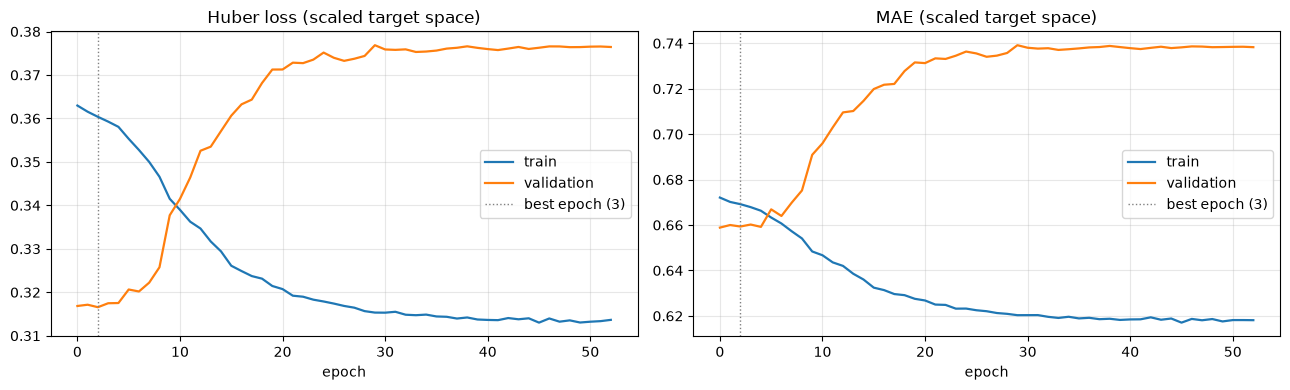

In [10]:
# =============================================================================
# 10 · TRAINING CURVES
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, key, title in ((axes[0], "loss", "Huber loss (scaled target space)"),
                       (axes[1], "mae",  "MAE (scaled target space)")):
    ax.plot(history.history[key], label="train", lw=1.6)
    ax.plot(history.history["val_" + key], label="validation", lw=1.6)
    ax.axvline(best_epoch - 1, color="grey", ls=":", lw=1, label=f"best epoch ({best_epoch})")
    ax.set_title(title); ax.set_xlabel("epoch"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 9 · Evaluation methodology

**Walk-forward:** the model is direct multi-horizon with stride-1 anchors, so evaluation *is*
walk-forward by construction — every anchor day in validation/test gets a 10-day forecast using only
information available on that day, with no retraining and no overlap tricks.

**Metrics, per horizon h = 1 … 10** (on reconstructed *prices*, plus direction on cumulative returns):

- RMSE, MAE, MAPE — price-path accuracy
- **Directional accuracy** — `sign(predicted cumulative return at h) == sign(actual)` — the metric that
  actually drives the app's UP/DOWN/HOLD signal

**Baselines — the honesty anchor.** Any forecast metric is meaningless in isolation, so every table
compares against:

- **Persistence** — price stays flat (the random-walk null; direction is undefined for it, so for
  direction we use…)
- **Always-up** — the base rate of positive moves (crypto drifts upward historically; a model must beat *this*, not 50%)
- **Drift** — price continues at the trailing 60-day mean daily return

A model that beats persistence on price error and always-up on direction — even by a few points — has
a real, defensible edge. That is the claim we make, and nothing more.

In [11]:
# =============================================================================
# 11 · EVALUATION HELPERS
# =============================================================================
def forecast_returns(m: keras.Model, X: np.ndarray) -> np.ndarray:
    """Model output → unscaled 10-day log-return matrix (n, HORIZON)."""
    return target_scaler.inverse_transform(m.predict(X, verbose=0)).astype(np.float64)


def to_price_paths(anchor_close: np.ndarray, logret_matrix: np.ndarray) -> np.ndarray:
    """P(t+k) = P(t) * exp(cumulative log-returns)."""
    return anchor_close[:, None] * np.exp(np.cumsum(logret_matrix, axis=1))


def per_horizon_table(actual_paths, pred_paths, actual_cum, pred_cum) -> pd.DataFrame:
    rows = []
    for h in range(HORIZON):
        a, p = actual_paths[:, h], pred_paths[:, h]
        rows.append({
            "horizon": f"day +{h+1}",
            "RMSE $":   float(np.sqrt(np.mean((a - p) ** 2))),
            "MAE $":    float(np.mean(np.abs(a - p))),
            "MAPE %":   float(np.mean(np.abs(a - p) / a) * 100),
            "dir_acc %": float((np.sign(pred_cum[:, h]) == np.sign(actual_cum[:, h])).mean() * 100),
        })
    return pd.DataFrame(rows).set_index("horizon")


def evaluate_split(split_name: str, split: dict, m: keras.Model, show_plots: bool = True) -> dict:
    """Full walk-forward evaluation of one split, model vs. baselines. Returns a metric dict."""
    X, y_raw   = split["X"], split["y"]
    anchor     = split["close"]
    drift_rate = split["drift"]
    dates      = split["dates"]

    pred_ret   = forecast_returns(m, X)
    pred_cum   = np.cumsum(pred_ret, axis=1)
    actual_cum = np.cumsum(y_raw, axis=1)
    pred_paths   = to_price_paths(anchor, pred_ret)
    actual_paths = to_price_paths(anchor, y_raw)

    # --- baselines -----------------------------------------------------------
    persist_paths = np.repeat(anchor[:, None], HORIZON, axis=1)               # flat price
    drift_cum     = drift_rate[:, None] * np.arange(1, HORIZON + 1)[None, :]  # trailing-mean drift
    drift_paths   = anchor[:, None] * np.exp(drift_cum)

    table = per_horizon_table(actual_paths, pred_paths, actual_cum, pred_cum)

    def _summary(paths, cum, label):
        return {
            "label": label,
            "MAPE_h1":  float(np.mean(np.abs(actual_paths[:, 0] - paths[:, 0]) / actual_paths[:, 0]) * 100),
            "MAPE_h10": float(np.mean(np.abs(actual_paths[:, -1] - paths[:, -1]) / actual_paths[:, -1]) * 100),
            "dir_h1":   float((np.sign(cum[:, 0]) == np.sign(actual_cum[:, 0])).mean() * 100) if cum is not None else float("nan"),
            "dir_h10":  float((np.sign(cum[:, -1]) == np.sign(actual_cum[:, -1])).mean() * 100) if cum is not None else float("nan"),
        }

    always_up_cum = np.ones_like(actual_cum)
    comparison = pd.DataFrame([
        _summary(pred_paths,    pred_cum,      "LSTM model"),
        _summary(persist_paths, None,          "persistence (flat)"),
        _summary(drift_paths,   drift_cum,     "drift (60d mean)"),
        _summary(persist_paths, always_up_cum, "always-up (direction base rate)"),
    ]).set_index("label")

    print(f"\n================ {split_name.upper()} — {len(X)} walk-forward forecasts "
          f"({dates.min().date()} → {dates.max().date()}) ================")
    print("\n--- LSTM per-horizon metrics ---")
    print(table.round(2).to_string())
    print("\n--- Model vs. baselines (MAPE % lower-better · direction % higher-better) ---")
    print(comparison.round(2).to_string())

    if show_plots:
        fig, axes = plt.subplots(2, 2, figsize=(14, 8))
        # (a) day+1 predicted vs actual price over time
        ax = axes[0, 0]
        ax.plot(dates, actual_paths[:, 0], label="actual (day +1)", lw=1.2)
        ax.plot(dates, pred_paths[:, 0], label="predicted (day +1)", lw=1.0, alpha=0.85)
        ax.set_title(f"{split_name}: next-day price — predicted vs actual")
        ax.legend(); ax.grid(alpha=0.3)
        # (b) directional accuracy per horizon vs baselines
        ax = axes[0, 1]
        hs = np.arange(1, HORIZON + 1)
        ax.plot(hs, [table["dir_acc %"].iloc[h] for h in range(HORIZON)], "o-", label="LSTM")
        ax.plot(hs, [(np.sign(actual_cum[:, h]) > 0).mean() * 100 for h in range(HORIZON)],
                "s--", label="always-up base rate")
        ax.plot(hs, [(np.sign(drift_cum[:, h]) == np.sign(actual_cum[:, h])).mean() * 100
                     for h in range(HORIZON)], "^--", label="drift")
        ax.axhline(50, color="grey", ls=":", lw=1)
        ax.set_title("directional accuracy by horizon"); ax.set_xlabel("days ahead")
        ax.set_ylabel("%"); ax.legend(); ax.grid(alpha=0.3)
        # (c) three example 10-day forecast fans
        ax = axes[1, 0]
        for j, idx in enumerate(np.linspace(0, len(X) - 1, 3, dtype=int)):
            span = pd.date_range(dates[idx] + pd.Timedelta(days=1), periods=HORIZON)
            ax.plot(span, actual_paths[idx], "-",  color=f"C{j}", lw=1.6,
                    label=f"actual  {dates[idx].date()}")
            ax.plot(span, pred_paths[idx],  "--", color=f"C{j}", lw=1.6,
                    label=f"forecast {dates[idx].date()}")
        ax.set_title("example 10-day forecast paths"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
        # (d) residual distribution, h=1 vs h=10
        ax = axes[1, 1]
        ax.hist((pred_cum[:, 0]  - actual_cum[:, 0])  * 100, bins=50, alpha=0.6, label="day +1")
        ax.hist((pred_cum[:, -1] - actual_cum[:, -1]) * 100, bins=50, alpha=0.6, label="day +10")
        ax.set_title("cumulative-return forecast error (pct-points)")
        ax.set_xlabel("error %"); ax.legend(); ax.grid(alpha=0.3)
        fig.suptitle(f"{split_name} diagnostics", y=1.01, fontsize=13)
        plt.tight_layout(); plt.show()

    return {
        "n_forecasts": int(len(X)),
        "period": [str(dates.min().date()), str(dates.max().date())],
        "per_horizon": json.loads(table.round(4).to_json(orient="index")),
        "vs_baselines": json.loads(comparison.round(4).to_json(orient="index")),
        "pred_cum": pred_cum, "actual_cum": actual_cum,   # kept in-memory for calibration
    }


================ VALIDATION — 356 walk-forward forecasts (2024-06-27 → 2025-06-17) ================

--- LSTM per-horizon metrics ---
            RMSE $      MAE $  MAPE %  dir_acc %
horizon                                         
day +1  2,406.5600 1,882.7900  2.2800    49.7200
day +2  3,511.4000 2,738.2200  3.3300    53.0900
day +3  4,333.0200 3,378.4900  4.1100    51.6900
day +4  5,053.6300 3,942.8700  4.8000    50.0000
day +5  5,652.0000 4,411.4600  5.3700    51.9700
day +6  6,189.0100 4,880.7600  5.9600    46.6300
day +7  6,618.9400 5,239.9300  6.4200    51.4000
day +8  6,978.4500 5,502.4000  6.7400    55.9000
day +9  7,341.0900 5,846.6700  7.1500    57.8700
day +10 7,676.0000 6,142.3100  7.5200    59.8300

--- Model vs. baselines (MAPE % lower-better · direction % higher-better) ---
                                 MAPE_h1  MAPE_h10  dir_h1  dir_h10
label                                                              
LSTM model                        2.2800    7.5200 49.7200  59

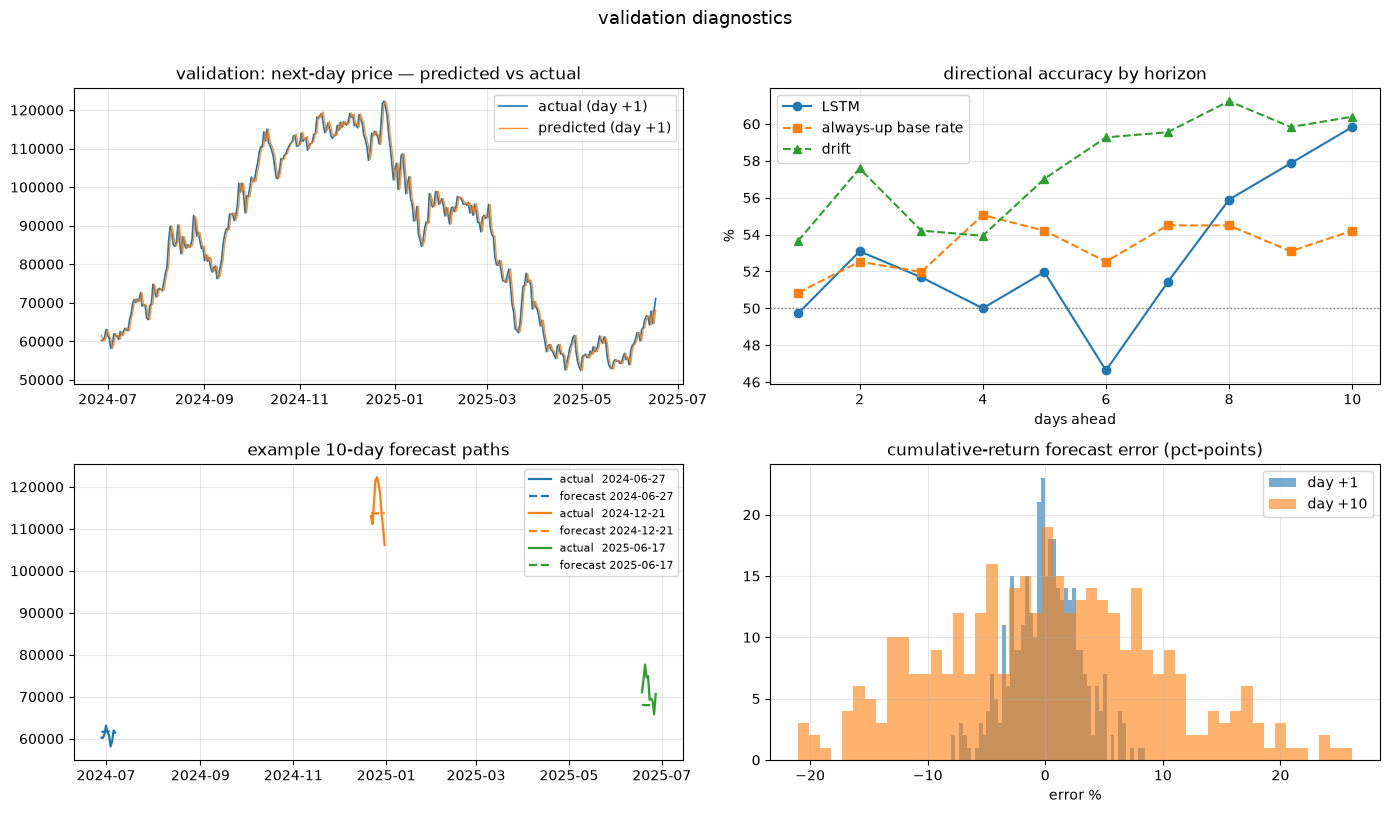

In [12]:
# =============================================================================
# 12 · VALIDATION EVALUATION  (first year of the test file — used for model
#      selection and for calibrating the trading-signal thresholds)
# =============================================================================
val_results = evaluate_split("validation", DATA["val"], model)


================ FINAL TEST — 1451 walk-forward forecasts (2025-06-27 → 2029-06-16) ================

--- LSTM per-horizon metrics ---
            RMSE $      MAE $  MAPE %  dir_acc %
horizon                                         
day +1  1,329.9600   806.4000  2.0300    48.7900
day +2  1,915.2200 1,171.9900  2.9600    50.4500
day +3  2,329.2000 1,449.5600  3.6900    51.1400
day +4  2,715.2700 1,680.6700  4.2900    51.6200
day +5  3,087.6100 1,896.8100  4.8400    51.2100
day +6  3,405.2800 2,081.1300  5.3100    51.4800
day +7  3,664.1600 2,220.3300  5.6700    50.7900
day +8  3,928.6900 2,390.9400  6.1400    50.5200
day +9  4,176.6700 2,545.4000  6.5500    49.8300
day +10 4,423.3300 2,696.8000  6.9500    50.3100

--- Model vs. baselines (MAPE % lower-better · direction % higher-better) ---
                                 MAPE_h1  MAPE_h10  dir_h1  dir_h10
label                                                              
LSTM model                        2.0300    6.9500 48.7900  5

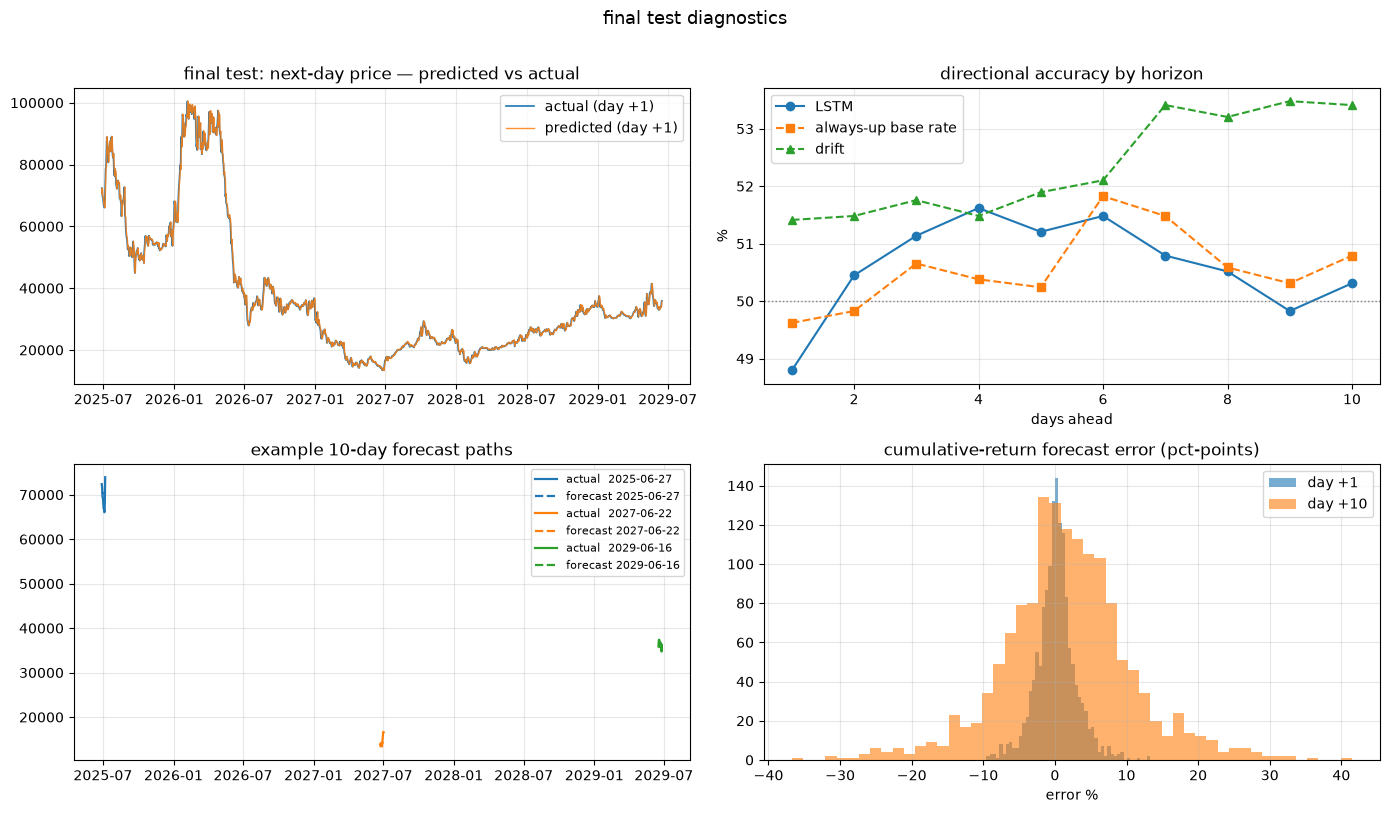

In [13]:
# =============================================================================
# 13 · FINAL TEST EVALUATION  (remaining test data — touched exactly once, here)
#
# Reminder: these dates (2025→2029) are a SYNTHETIC future series, so this
# measures generalization to a simulated regime. That caveat ships in the
# metadata and must accompany any quoted number.
# =============================================================================
test_results = evaluate_split("final test", DATA["test"], model)

## 10 · Trading-signal calibration — UP / DOWN / HOLD

The app never shows a raw number without judgment. The 10-day cumulative forecast `R` is converted
into a discrete signal using thresholds **calibrated on validation only**:

- `move_threshold` = median |predicted 10-day move| on validation → by construction, roughly half of
  all days classify as **HOLD**. An honest model of a near-random-walk asset *should* say HOLD often.
- `uncertainty` = the standard deviation of the validation forecast error on the 10-day cumulative
  return — shipped with every forecast so the UI can display "±x%" instead of implying certainty.
- **Confidence** = `min(|R| / (2·move_threshold), 1)` — deliberately saturating, so the UI can never
  display an overclaimed probability.

We also report the **acting hit-rate**: among final-test days where the signal was *not* HOLD, how
often was the direction right? That single number is what a user who follows the signal actually
experiences — it goes into the metadata and onto `bitcoin.html`.

In [14]:
# =============================================================================
# 14 · SIGNAL CALIBRATION
# =============================================================================
val_pred_cum10 = val_results["pred_cum"][:, -1]
val_act_cum10  = val_results["actual_cum"][:, -1]

MOVE_THRESHOLD  = float(np.quantile(np.abs(val_pred_cum10), 0.5))
CUM10_ERR_STD   = float(np.std(val_pred_cum10 - val_act_cum10))


def classify_signal(pred_cum10: float) -> dict:
    """Convert a 10-day cumulative log-return forecast into the app-facing signal."""
    if pred_cum10 > MOVE_THRESHOLD:
        signal = "UP"
    elif pred_cum10 < -MOVE_THRESHOLD:
        signal = "DOWN"
    else:
        signal = "HOLD"
    return {
        "signal": signal,
        "confidence": round(float(min(abs(pred_cum10) / (2 * MOVE_THRESHOLD), 1.0)), 3),
        "expected_move_pct": round(float(np.expm1(pred_cum10) * 100), 2),
        "uncertainty_pct": round(float(np.expm1(CUM10_ERR_STD) * 100), 2),
    }


# --- acting hit-rate on the FINAL TEST split ---------------------------------
test_pred_cum10 = test_results["pred_cum"][:, -1]
test_act_cum10  = test_results["actual_cum"][:, -1]
signals = np.where(test_pred_cum10 > MOVE_THRESHOLD, "UP",
          np.where(test_pred_cum10 < -MOVE_THRESHOLD, "DOWN", "HOLD"))
acting = signals != "HOLD"
acting_hit_rate = float((np.sign(test_pred_cum10[acting]) ==
                         np.sign(test_act_cum10[acting])).mean() * 100) if acting.any() else float("nan")
base_rate = float(max((test_act_cum10 > 0).mean(), (test_act_cum10 < 0).mean()) * 100)

signal_counts = pd.Series(signals).value_counts()
print(f"move_threshold (validation-median |move|): {MOVE_THRESHOLD:+.4f} "
      f"(≈ {np.expm1(MOVE_THRESHOLD)*100:.2f}% over 10 days)")
print(f"forecast uncertainty (1σ, 10-day cum)    : ±{np.expm1(CUM10_ERR_STD)*100:.2f}%")
print(f"\nfinal-test signal distribution:\n{signal_counts.to_string()}")
print(f"\nacting hit-rate (direction correct when signal ≠ HOLD): {acting_hit_rate:.1f}% "
      f"on {int(acting.sum())} acting days")
print(f"majority-direction base rate on the same period       : {base_rate:.1f}%")
print("\nexample — signal for the most recent available day:")
print(json.dumps(classify_signal(float(test_pred_cum10[-1])), indent=2))

move_threshold (validation-median |move|): +0.0055 (≈ 0.55% over 10 days)
forecast uncertainty (1σ, 10-day cum)    : ±9.77%

final-test signal distribution:
UP      925
HOLD    432
DOWN     94

acting hit-rate (direction correct when signal ≠ HOLD): 50.9% on 1019 acting days
majority-direction base rate on the same period       : 50.8%

example — signal for the most recent available day:
{
  "signal": "UP",
  "confidence": 0.525,
  "expected_move_pct": 0.58,
  "uncertainty_pct": 9.77
}


## 11 · Ship the artifacts + verify the exact serving path

Three artifacts, consumed by `server.ipynb`:

| Artifact | Contents |
|---|---|
| `data/btc/model.keras` | best-validation weights (Keras native format) |
| `data/btc/scalers.pkl` | fitted `RobustScaler` (features) + `StandardScaler` (targets) + feature list + lookback/horizon + clip bounds — the complete serving contract |
| `data/btc/metadata.json` | config, data ranges, all validation & test metrics, baseline comparison, calibrated signal thresholds, honesty caveats |

Two verification steps follow, because "it trained" is not "it serves":

1. **Reload check** — load `model.keras` from disk and assert its predictions are identical to the
   in-memory model.
2. **Serving-path rehearsal** — rebuild features from only a **250-day tail** of raw OHLCV (what the
   server will actually have), verify they match the full-history computation to float tolerance
   (EWM indicators need convergence room — 250 days is plenty for span ≤ 26), then produce and print
   a real 10-day forecast with its signal. This is byte-for-byte the code path `server.ipynb` replicates.

In [15]:
# =============================================================================
# 15 · SAVE ARTIFACTS · RELOAD CHECK · SERVING-PATH REHEARSAL
# =============================================================================
# --- 15.1  scalers + serving contract ----------------------------------------
with open(SCALERS_PATH, "wb") as fh:
    pickle.dump({
        "feature_scaler": feature_scaler,
        "target_scaler":  target_scaler,
        "feature_names":  FEATURE_NAMES,
        "lookback":       CONFIG["lookback"],
        "horizon":        HORIZON,
        "target_clip":    [float(CLIP_LO), float(CLIP_HI)],
        "serving_context_days": 250,
    }, fh)

# --- 15.2  metadata -----------------------------------------------------------
def _strip_arrays(res: dict) -> dict:
    return {k: v for k, v in res.items() if k not in ("pred_cum", "actual_cum")}

metadata = {
    "model_name": "btc_multihorizon_lstm",
    "created_at": datetime.now(timezone.utc).isoformat(),
    "tensorflow_version": tf.__version__,
    "seed": SEED,
    "config": {k: v for k, v in CONFIG.items()},
    "feature_names": FEATURE_NAMES,
    "data": {
        "clean_rows": int(len(df)),
        "clean_range": [str(df.index.min().date()), str(df.index.max().date())],
        "train_last_date": str(TRAIN_LAST_DATE.date()),
        "validation_range": [str(TEST_START_DATE.date()), str(VAL_END_DATE.date())],
        "samples": {name: int(len(DATA[name]["X"])) for name in ("train", "val", "test")},
        "target_clip_bounds": [float(CLIP_LO), float(CLIP_HI)],
    },
    "training": {
        "best_epoch": best_epoch,
        "best_val_loss": float(min(history.history["val_loss"])),
        "epochs_ran": len(history.history["val_loss"]),
    },
    "validation_metrics": _strip_arrays(val_results),
    "final_test_metrics": _strip_arrays(test_results),
    "signal_calibration": {
        "move_threshold_log_return": MOVE_THRESHOLD,
        "cum10_error_std_log_return": CUM10_ERR_STD,
        "final_test_acting_hit_rate_pct": acting_hit_rate,
        "final_test_majority_base_rate_pct": base_rate,
        "final_test_signal_counts": {k: int(v) for k, v in signal_counts.items()},
    },
    "caveats": [
        "Daily BTC returns are close to a random walk; this model provides decision support with "
        "quantified uncertainty, not price prediction.",
        "The test file's 2024-2029 dates are a synthetic future series; final-test metrics measure "
        "generalization to a simulated regime.",
        "Signals are informational only and must be displayed with the uncertainty band and a "
        "not-financial-advice disclaimer.",
    ],
}
with open(METADATA_PATH, "w", encoding="utf-8") as fh:
    json.dump(metadata, fh, indent=2, ensure_ascii=False)

# --- 15.3  reload check ----------------------------------------------------------
reloaded = keras.models.load_model(MODEL_PATH)
probe = DATA["test"]["X"][-4:]
assert np.allclose(reloaded.predict(probe, verbose=0),
                   model.predict(probe, verbose=0), atol=1e-5), "reloaded model diverges!"
print(f"reload check       : PASSED — {MODEL_PATH} reproduces in-memory predictions")

# --- 15.4  serving-path rehearsal -------------------------------------------------
SERVING_CONTEXT_DAYS = 250
tail_ohlcv = df.tail(SERVING_CONTEXT_DAYS)
tail_feat = compute_features(tail_ohlcv).dropna()

# features computed from the 250-day tail must match the full-history computation
drift_check = float(np.max(np.abs(
    tail_feat.iloc[-1].to_numpy() - feat_raw.loc[tail_feat.index[-1]].to_numpy())))
assert drift_check < 1e-6, f"tail-context features diverge from full history (max diff {drift_check:.2e})"
print(f"serving features   : PASSED — 250-day-tail computation matches full history "
      f"(max |diff| {drift_check:.2e})")

window = feature_scaler.transform(
    tail_feat.tail(CONFIG["lookback"]).to_numpy()).astype(np.float32)[None, ...]
serve_ret = target_scaler.inverse_transform(reloaded.predict(window, verbose=0))[0]
last_date, last_close = tail_feat.index[-1], float(df["Close"].loc[tail_feat.index[-1]])
serve_prices = last_close * np.exp(np.cumsum(serve_ret))
serve_signal = classify_signal(float(np.sum(serve_ret)))

forecast_table = pd.DataFrame({
    "date": pd.date_range(last_date + pd.Timedelta(days=1), periods=HORIZON).date,
    "forecast_close_usd": serve_prices.round(2),
    "cum_move_pct": (np.expm1(np.cumsum(serve_ret)) * 100).round(2),
})
print(f"\n=== SERVING REHEARSAL — 10-day forecast from {last_date.date()} "
      f"(last close ${last_close:,.2f}) ===")
print(forecast_table.to_string(index=False))
print(f"\nsignal: {json.dumps(serve_signal, indent=2)}")
print(f"\nartifacts written:\n  {MODEL_PATH}\n  {SCALERS_PATH}\n  {METADATA_PATH}")
print("\nNOTE: the dates above come from the synthetic tail of btc_test.csv — this cell validates the")
print("PIPELINE; in production server.ipynb feeds this exact code path with live prices (250-day context).")

reload check       : PASSED — data/btc/model.keras reproduces in-memory predictions
serving features   : PASSED — 250-day-tail computation matches full history (max |diff| 4.66e-10)

=== SERVING REHEARSAL — 10-day forecast from 2029-06-26 (last close $36,074.68) ===
      date  forecast_close_usd  cum_move_pct
2029-06-27         36,096.3789        0.0600
2029-06-28         36,078.4688        0.0100
2029-06-29         36,069.0586       -0.0200
2029-06-30         36,078.1602        0.0100
2029-07-01         36,086.7500        0.0300
2029-07-02         36,127.5898        0.1500
2029-07-03         36,114.6992        0.1100
2029-07-04         36,121.1211        0.1300
2029-07-05         36,142.0195        0.1900
2029-07-06         36,128.6484        0.1500

signal: {
  "signal": "HOLD",
  "confidence": 0.136,
  "expected_move_pct": 0.15,
  "uncertainty_pct": 9.77
}

artifacts written:
  data/btc/model.keras
  data/btc/scalers.pkl
  data/btc/metadata.json

NOTE: the dates above come from the

## 12 · Conclusions, limitations, and what `server.ipynb` consumes

**What was built.** A leakage-audited, walk-forward-evaluated, multi-horizon LSTM forecaster trained
on ~11 years of cleaned daily BTC data, with train-only scaling, train-only target clipping,
validation-only model selection and threshold calibration, and a once-touched final test set —
benchmarked at every step against persistence, drift, and base-rate baselines.

**How to read the numbers.** Expect the model's edge to be *modest and honest*: directional accuracy
a few points above the always-up base rate at short horizons, decaying toward the base rate by
day +10, with price MAPE close to (ideally slightly better than) persistence. On a near-random-walk
asset, *that is what a real edge looks like* — a model claiming much more is broken or leaking.

**Hard limitations (also shipped in `metadata.json → caveats`):**
1. The 2025–2029 test series is synthetic; real-world performance must be monitored on live data.
2. The model knows nothing about news, regulation, ETF flows, or halvings — regime breaks will not be anticipated.
3. Signals are decision support with an explicit ±uncertainty band, never financial advice; the UI
   contract requires displaying both.

**Serving contract for `server.ipynb`:** load `model.keras` + `scalers.pkl` once at startup → keep a
250-day OHLCV context (live API with cached fallback) → `compute_features(...).dropna()` → scale the
last `lookback` rows → predict → inverse-transform → reconstruct prices → `classify_signal(...)` →
serve `/api/btc/forecast`. Every constant needed is inside the two artifact files — no magic numbers
live outside them.